# Assignment 6: Image Classification on CIFAR-10 (ANN vs CNN)

## This notebook is from Xavier Andres Soto Baron UCF ID: 5601517

**Objective**
* Practicing Keras and implementing ANN and CNN using Keras
* Build and compare for image classification using :
  - ANN (Artificial Neural Network)
  - CNN (Convolutional Neural Network)
Understand why CNN works better for images.


**This notebook is incomplete. You need to carefully read the codes and instructions. Some places you need to add some code and in some places you need to explain with text and comments. Make sure your submitted notebook has all the output including the full code**
 <br>
<font color="red"> If you see the label <u><b>#TODO </b></u> anywhere in the notebook, it indicates that you need to complete that section by writing code or adding text to answer the question.</font>

In [ ]:
#importing some necessary libraries
from keras.datasets import cifar10
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
(50000, 32, 32, 3) (10000, 32, 32, 3) (50000, 1) (10000, 1)


### Discussion about the numbers
What do the numbers (50000, 32, 32, 3), (10000, 32, 32, 3), (50000, 1), and (10000, 1) represent in the output above??
* **(50000, 32, 32, 3):** This represents the training images. There are 50,000 individual images, each with a height of 32 pixels, a width of 32 pixels, and 3 color channels (Red, Green, Blue).
* **(10000, 32, 32, 3):** This represents the testing images. There are 10,000 images used for evaluating the model after training, maintaining the same 32x32x3 dimensions.
* **(50000, 1)** This represents the training labels. It is a column vector containing 50,000 integers (ranging from 0 to 9), where each integer corresponds to a specific class (e.g., 0 for airplane, 1 for automobile
* **(10000, 1):** This represents the testing labels. It contains the 10,000 ground-truth integers used to verify the model's predictions on the test set






array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
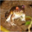

In [ ]:
#checking one image data
x_train[0]

## Visualization (Given)

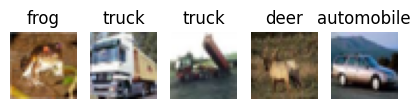

In [ ]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(5,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.show()

## Task : Show 10 Random Images

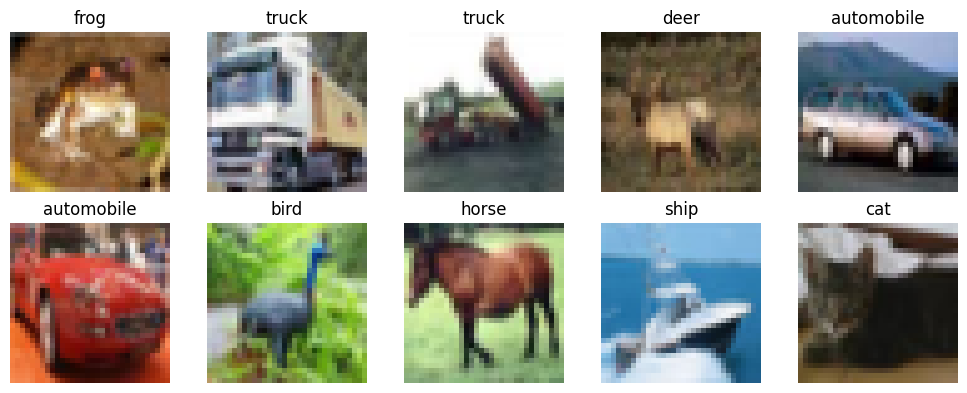

In [ ]:
# Visualizing a larger sample of images (e.g., 10 images in 2 rows)
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    # Accessing the class name using the label index in y_train
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()

plt.show()

# Part 1: Developing Artifican Neural Network (Follow the codes from the slide!)

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout

## Preprocessing

In [ ]:
num_pixels = x_train.shape[1] * x_train.shape[2] * x_train.shape[3]  #calculating total number of features for each image
print(num_pixels)

x_train = x_train.reshape(x_train.shape[0], num_pixels).astype('float32') #reshape x_train to number of images X number of features calculated above
x_test = x_test.reshape(x_test.shape[0], num_pixels).astype('float32') #reshape x_test to number of images X number of features calculated above
print(x_train.shape, x_test.shape)  #this should output (50000, 3072) (10000, 3072)

3072
(50000, 3072) (10000, 3072)


In [ ]:
x_train[0] #just printing one image to see if it has been reshaped

array([ 59.,  62.,  63., ..., 123.,  92.,  72.], dtype=float32)

In [ ]:
# Normalize pixel values to [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(x_train.shape, y_train.shape) #should print this (50000, 3072) (50000, 10)

(50000, 3072) (50000, 10)


In [ ]:
num_classes = 10
# define simple model
def simplenn_model():
  model = models.Sequential()

  model.add(Dense(1000, input_dim=num_pixels, kernel_initializer='normal', activation='relu'))
  model.add(Dense(100, kernel_initializer='normal', activation='relu'))
  model.add(Dense(50, kernel_initializer='normal', activation='relu'))
  model.add(Dense(num_classes, kernel_initializer='normal', activation='softmax'))

  # Compile
  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

  return model




In [ ]:
from tensorflow.keras import models
from tensorflow.keras.layers import Dense

# Build and Fit
model = simplenn_model()
model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10, batch_size=200, verbose=2)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 - 5s - 19ms/step - accuracy: 0.2944 - loss: 1.9252 - val_accuracy: 0.3688 - val_loss: 1.7475
Epoch 2/10
250/250 - 2s - 6ms/step - accuracy: 0.3800 - loss: 1.7163 - val_accuracy: 0.4057 - val_loss: 1.6675
Epoch 3/10
250/250 - 2s - 7ms/step - accuracy: 0.4158 - loss: 1.6262 - val_accuracy: 0.4315 - val_loss: 1.5900
Epoch 4/10
250/250 - 1s - 5ms/step - accuracy: 0.4398 - loss: 1.5634 - val_accuracy: 0.4329 - val_loss: 1.5745
Epoch 5/10
250/250 - 1s - 5ms/step - accuracy: 0.4568 - loss: 1.5214 - val_accuracy: 0.4518 - val_loss: 1.5502
Epoch 6/10
250/250 - 1s - 5ms/step - accuracy: 0.4766 - loss: 1.4747 - val_accuracy: 0.4751 - val_loss: 1.4775
Epoch 7/10
250/250 - 1s - 5ms/step - accuracy: 0.4882 - loss: 1.4386 - val_accuracy: 0.4856 - val_loss: 1.4601
Epoch 8/10
250/250 - 3s - 11ms/step - accuracy: 0.4976 - loss: 1.4091 - val_accuracy: 0.4723 - val_loss: 1.4690
Epoch 9/10
250/250 - 1s - 5ms/step - accuracy: 0.5067 - loss: 1.3837 - val_accuracy: 0.4893 - val_loss: 1.4414

##TASK: What was the last accuracy from training set and validation set?

- Accuracy from training set: Around 52% (~52%)
- Validation Set: Around 48% (~48%)

In [ ]:
# Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1000)           │     3,073,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │       100,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,535,982 (36.38 MB)

 Trainable params: 3,178,660 (12.13 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,357,322 (24.25 MB)

In [ ]:
print(model.evaluate(x_test, y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4953 - loss: 1.4234
[1.42343270778656, 0.4952999949455261]


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Convert one-hot TRUE labels to integer indices
y_true_indices = np.argmax(y_test, axis=1)

# 2. Get model predictions (probabilities)
y_pred_probs = model.predict(x_test)

# 3. Convert predicted probabilities to integer indices
y_pred_indices = np.argmax(y_pred_probs, axis=1)

# 4. Generate the report
print(classification_report(y_true_indices, y_pred_indices))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.51      0.61      0.55      1000
           1       0.63      0.59      0.61      1000
           2       0.39      0.35      0.37      1000
           3       0.36      0.30      0.33      1000
           4       0.45      0.38      0.42      1000
           5       0.44      0.34      0.38      1000
           6       0.43      0.68      0.53      1000
           7       0.63      0.51      0.56      1000
           8       0.53      0.71      0.61      1000
           9       0.59      0.49      0.53      1000

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.49     10000
weighted avg       0.50      0.50      0.49     10000



Part 2: Developing Convolutional Neural Network (CNN) (Follow the codes from the slide!)

In [ ]:
# To see plots "in-line" in your Notebook, you must use this command
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7,7) # Make the figures a bit bigger

import keras
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
from keras.layers import Conv2D, MaxPooling2D
from keras import layers, models, Input
from keras import backend as K

In [ ]:
#read the data set
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(50000, 32, 32, 3) (10000, 32, 32, 3) (50000, 1) (10000, 1)


In [ ]:
#reshape train test based based backend
# input image dimensions
img_rows, img_cols = x_train.shape[1], x_train.shape[2]
channel = 3 #fill out number of channel for our images
#don’t forget. X_train.shape was (60000, 28, 28). In our case it is just one channel

if K.image_data_format() == 'channels_first':
   x_train = x_train.reshape(x_train.shape[0], channel, img_rows, img_cols) #(50000, 3, 32, 32)
   x_test = x_test.reshape(x_test.shape[0], channel, img_rows, img_cols)
   input_shape = (channel, img_rows, img_cols)
   print('it was channels_first')
else:

   x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, channel)
   x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, channel)
   input_shape = (img_rows, img_cols, channel)
   print('it was channels_last')

it was channels_last


#Data Preprocessing

In [ ]:
#normalize training set
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

#perform one hot encoding to target

num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
print(y_test)
#now y_test looks like this

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]


In [ ]:
#defining our CNN
#Fill out all the following blanks
# CNN Definition
cnn_model = models.Sequential()
cnn_model.add(Input(shape=input_shape))
cnn_model.add(Conv2D(32, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

cnn_model.add(layers.Flatten())

cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(10, activation='softmax'))

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Setup the compile with adam optmizer, categorical cross entropy loss ad accuracy metrics
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
#Train the model with trian set, 64 batch size and 10 epoch
history_cnn = cnn_model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.4584 - loss: 1.5104 - val_accuracy: 0.5544 - val_loss: 1.2622
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5910 - loss: 1.1681 - val_accuracy: 0.6172 - val_loss: 1.0943
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6402 - loss: 1.0300 - val_accuracy: 0.6334 - val_loss: 1.0486
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6731 - loss: 0.9405 - val_accuracy: 0.6584 - val_loss: 0.9813
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6922 - loss: 0.8821 - val_accuracy: 0.6744 - val_loss: 0.9542
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7151 - loss: 0.8223 - val_accuracy: 0.6846 - val_loss: 0.9235
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7295 - loss: 0.7773 - val_accuracy: 0.6952 - val_loss: 0.8902
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7439 - loss: 0.7367 - val_accuracy: 

##TASK: What was the last accuracy from training set and Validation set**

- Training Set: ~75%
- Validation Set: ~70%

In [ ]:
print(cnn_model.evaluate(x_test, y_test))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6978 - loss: 0.9074
[0.9074367880821228, 0.6977999806404114]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 53.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/visualkeras/layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


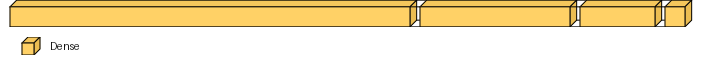

In [ ]:
#let us visualize the model
!pip install visualkeras
import visualkeras #!pip install visualkeras, if it is not available to you yet
for layer in model.layers:
    layer.output_shape = layer.output.shape
visualkeras.layered_view(model, legend=True)

#TASK #TODO Comparison
Which model performed better and why?


The **convolutional Neural Network (CNN)** performed significantly better than Artificial Neural Network (ANN)

- **Spatial Hierarchy:** The ANN treats images as flat vectors, meaning it loses the relationship between neighboring pixels. If a feature (like a "bird's beak") moves a few pixels to the left, the ANN sees it as a completely different input. The CNN uses filters to maintain spatial context.

- **Parameter Efficiency:** In the ANN, every pixel is connected to every neuron in the hidden layer, leading to a massive number of parameters that are prone to overfitting. The CNN uses weight sharing, this means that the same filter is applied across the entire image, drastically reducing the parameter count while increasing feature detection capability.

- **Translation Invariance:** Thanks to the MaxPooling layers, the CNN is much better at recognizing objects regardless of their position in the frame.